In [2]:
# 1: Import thư viện và khai báo đường dẫn

from pathlib import Path
import re
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Tải stopwords nếu máy chưa có
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

# Xác định thư mục gốc của project
project_root = Path.cwd()

# Nếu đang chạy trong folder notebook thì quay lên 1 cấp
if project_root.name.lower() == "notebook":
    project_root = project_root.parent

data_dir = project_root / "data"
model_dir = project_root / "model"

model_dir.mkdir(exist_ok=True)

print("Project root:", project_root)
print("Data folder:", data_dir)
print("Model folder:", model_dir)

Project root: c:\Users\Admin\Desktop\phishing_email\phishing_email
Data folder: c:\Users\Admin\Desktop\phishing_email\phishing_email\data
Model folder: c:\Users\Admin\Desktop\phishing_email\phishing_email\model


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
# 2: Khai báo danh sách dataset


DATASET_FILES = {
    "CEAS_08": data_dir / "CEAS_08.csv",
    "Nazario": data_dir / "Nazario.csv",
    "Nigerian_Fraud": data_dir / "Nigerian_Fraud.csv",
    "SpamAssasin": data_dir / "SpamAssasin.csv",
}

for name, path in DATASET_FILES.items():
    print(name, "->", path, "| Exists:", path.exists())

CEAS_08 -> c:\Users\Admin\Desktop\phishing_email\phishing_email\data\CEAS_08.csv | Exists: True
Nazario -> c:\Users\Admin\Desktop\phishing_email\phishing_email\data\Nazario.csv | Exists: True
Nigerian_Fraud -> c:\Users\Admin\Desktop\phishing_email\phishing_email\data\Nigerian_Fraud.csv | Exists: True
SpamAssasin -> c:\Users\Admin\Desktop\phishing_email\phishing_email\data\SpamAssasin.csv | Exists: True


In [4]:
# 3: Hàm chuẩn hóa dataset
# Mục tiêu: đưa mọi dataset về cùng dạng:
# text, label, dataset_source


def map_label(value):
    """
    Chuẩn hóa label về dạng:
    0 = legitimate
    1 = phishing/spam/fraud
    """

    if pd.isna(value):
        return None

    value_str = str(value).strip().lower()

    if value_str in ["1", "phishing", "spam", "fraud", "malicious", "bad"]:
        return 1

    if value_str in ["0", "legitimate", "ham", "normal", "benign", "good"]:
        return 0

    return None


def find_text_columns(df):
    """
    Tìm cột văn bản trong dataset.
    Ưu tiên subject + body.
    Nếu không có thì tìm các cột thường gặp như text, email, message, content.
    """

    columns = [col.lower() for col in df.columns]
    col_map = {col.lower(): col for col in df.columns}

    subject_col = col_map.get("subject")
    body_col = col_map.get("body")

    if subject_col and body_col:
        return subject_col, body_col

    possible_text_cols = ["text", "email", "message", "content", "body"]

    for col in possible_text_cols:
        if col in col_map:
            return None, col_map[col]

    raise ValueError(
        f"Không tìm thấy cột văn bản. Các cột hiện có: {df.columns.tolist()}"
    )


def find_label_column(df):
    """
    Tìm cột nhãn trong dataset.
    """

    col_map = {col.lower(): col for col in df.columns}

    possible_label_cols = ["label", "class", "category", "target", "type"]

    for col in possible_label_cols:
        if col in col_map:
            return col_map[col]

    return None


def load_and_standardize_dataset(dataset_name, file_path):
    """
    Đọc 1 dataset và chuẩn hóa thành:
    text, label, dataset_source
    """

    if not file_path.exists():
        raise FileNotFoundError(f"Không tìm thấy file: {file_path}")

    df_raw = pd.read_csv(file_path)

    print("\n==============================")
    print("Dataset:", dataset_name)
    print("Shape:", df_raw.shape)
    print("Columns:", df_raw.columns.tolist())

    subject_col, body_col = find_text_columns(df_raw)

    if subject_col and body_col:
        df_raw[subject_col] = df_raw[subject_col].fillna("")
        df_raw[body_col] = df_raw[body_col].fillna("")
        text = df_raw[subject_col].astype(str) + " " + df_raw[body_col].astype(str)
    else:
        df_raw[body_col] = df_raw[body_col].fillna("")
        text = df_raw[body_col].astype(str)

    label_col = find_label_column(df_raw)

    if label_col is None:
        if dataset_name in ["Nazario", "Nigerian_Fraud"]:
            label = pd.Series([1] * len(df_raw))
            print("Không thấy cột label. Tạm gán toàn bộ dataset này là label = 1.")
        else:
            raise ValueError(
                f"Dataset {dataset_name} không có cột label. "
                f"Bạn cần kiểm tra lại file hoặc thêm cột label."
            )
    else:
        label = df_raw[label_col].apply(map_label)

    df_standard = pd.DataFrame(
        {"text": text, "label": label, "dataset_source": dataset_name}
    )

    df_standard = df_standard.dropna(subset=["text", "label"])
    df_standard["label"] = df_standard["label"].astype(int)

    print("After standardize:", df_standard.shape)
    print(df_standard["label"].value_counts())

    return df_standard

In [5]:
# 4: Đọc và gộp 4 dataset

all_datasets = []

for dataset_name, file_path in DATASET_FILES.items():
    df_temp = load_and_standardize_dataset(dataset_name, file_path)
    all_datasets.append(df_temp)

df = pd.concat(all_datasets, ignore_index=True)

print("\n===== FINAL MERGED DATASET =====")
print(df.shape)
print(df.head())
print(df["dataset_source"].value_counts())
print(df["label"].value_counts())


Dataset: CEAS_08
Shape: (39154, 7)
Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']
After standardize: (39154, 3)
label
1    21842
0    17312
Name: count, dtype: int64

Dataset: Nazario
Shape: (1565, 7)
Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label']
After standardize: (1565, 3)
label
1    1565
Name: count, dtype: int64

Dataset: Nigerian_Fraud
Shape: (3332, 7)
Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label']
After standardize: (3332, 3)
label
1    3332
Name: count, dtype: int64

Dataset: SpamAssasin
Shape: (5809, 7)
Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']
After standardize: (5809, 3)
label
0    4091
1    1718
Name: count, dtype: int64

===== FINAL MERGED DATASET =====
(49860, 3)
                                                text  label dataset_source
0  Never agree to be a loser Buck up, your troubl...      1        CEAS_08
1  Befriend Jenna Jameson \r\nUpgrade your

In [6]:
# 5: Tiền xử lý dữ liệu

from nltk.corpus import stopwords

# Tải danh sách stopwords tiếng Anh nếu máy chưa có
nltk.download("stopwords")

# Tạo tập stopwords để loại bỏ các từ phổ biến ít mang ý nghĩa phân loại
stop_words = set(stopwords.words("english"))
nltk.download("wordnet") 
nltk.download("omw-1.4") 

lemmatizer = WordNetLemmatizer()

def tien_xu_ly_du_lieu(text): 
    text = str(text).lower() 
    text = re.sub(r"http\S+|www\S+", " URLTOKEN ", text) 
    text = re.sub(r"\S+@\S+", " EMAILTOKEN ", text) 
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text) 
    text = re.sub(r"\s+", " ", text).strip()
    words = text.split() 
    words = [ lemmatizer.lemmatize(word) for word in words if word not in stop_words ]
    return " ".join(words)


df["clean_text"] = df["text"].apply(tien_xu_ly_du_lieu)

df[["text", "clean_text", "label", "dataset_source"]].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...


,text,clean_text,label,dataset_source
0,"Never agree to be a loser Buck up, your troubl...",never agree loser buck trouble caused small di...,1,CEAS_08
1,Befriend Jenna Jameson \r\nUpgrade your sex an...,befriend jenna jameson upgrade sex pleasure te...,1,CEAS_08
2,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...,cnn com daily top 10 daily top 10 cnn com top ...,1,CEAS_08
3,Re: svn commit: r619753 - in /spamassassin/tru...,svn commit r619753 spamassassin trunk lib mail...,0,CEAS_08
4,SpecialPricesPharmMoreinfo \r\nWelcomeFastShip...,specialpricespharmmoreinfo welcomefastshipping...,1,CEAS_08


In [7]:
# Kiểm tra dữ liệu sau khi tiền xử lý

# 1. Kiểm tra số lượng email theo từng dataset
print("===== SỐ LƯỢNG EMAIL THEO DATASET =====")
print(df["dataset_source"].value_counts())

print("\n===== PHÂN BỐ LABEL THEO DATASET =====")
print(pd.crosstab(df["dataset_source"], df["label"]))

# 2. Xem mỗi dataset 3 dòng mẫu
print("\n===== XEM MẪU DỮ LIỆU THEO TỪNG DATASET =====")

for source in df["dataset_source"].unique():
    print(f"\n--- Dataset: {source} ---")
    display(
        df[df["dataset_source"] == source][
            ["text", "clean_text", "label", "dataset_source"]
        ].sample(n=3, random_state=42)
    )

# 3. Kiểm tra một số stopwords phổ biến có còn trong clean_text không
sample_stopwords = ["the", "is", "are", "to", "of", "and", "your", "you"]

print("\n===== KIỂM TRA STOPWORDS =====")

for word in sample_stopwords:
    count = df["clean_text"].str.split().apply(lambda words: word in words).sum()
    print(f"'{word}' xuất hiện trong clean_text: {count} dòng")

===== SỐ LƯỢNG EMAIL THEO DATASET =====
dataset_source
CEAS_08           39154
SpamAssasin        5809
Nigerian_Fraud     3332
Nazario            1565
Name: count, dtype: int64

===== PHÂN BỐ LABEL THEO DATASET =====
label               0      1
dataset_source              
CEAS_08         17312  21842
Nazario             0   1565
Nigerian_Fraud      0   3332
SpamAssasin      4091   1718

===== XEM MẪU DỮ LIỆU THEO TỪNG DATASET =====

--- Dataset: CEAS_08 ---


,text,clean_text,label,dataset_source
5657,Re: what are the criteria for being listed in\...,criterion listed sa blacklist current also sa ...,0,CEAS_08
2133,Guaranteed Erection Fast \r\nSize DOES matter ...,guaranteed erection fast size matter change li...,1,CEAS_08
12114,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...,cnn com daily top 10 daily top 10 cnn com top ...,1,CEAS_08



--- Dataset: Nazario ---


,text,clean_text,label,dataset_source
39681,email-alert@verification.com =?utf-8?Q?=E2=9C=...,EMAILTOKEN utf 8 q e2 9c 94 mail alert b11nec ...,1,Nazario
39425,Confirm your informations ! Apple : Confirm yo...,confirm information apple confirm information ...,1,Nazario
40556,"A document titled ""Proposal"" has been shared w...",document titled proposal shared onedrive docum...,1,Nazario



--- Dataset: Nigerian_Fraud ---


,text,clean_text,label,dataset_source
41157,"Re; Letter Dear Friend,\n\nWarmest greetings i...",letter dear friend warmest greeting name allah...,1,Nigerian_Fraud
43393,"Urgent Assistance Requested Dear Sir / Madam,\...",urgent assistance requested dear sir madam mr ...,1,Nigerian_Fraud
42064,urgent response FROM MISS SAVANA PRISCA\nABIDJ...,urgent response miss savana prisca abidjan ivo...,1,Nigerian_Fraud



--- Dataset: SpamAssasin ---


,text,clean_text,label,dataset_source
44552,"Re: whoa >>>>> ""J"" == James Rogers writes: ...",whoa j james rogers writes j selling software ...,0,SpamAssasin
47215,Re: spam maps Lucas Gonze wrote:\n>>- Joe\n>>\...,spam map lucas gonze wrote joe p hate everybod...,0,SpamAssasin
48006,[Lockergnome Digital Media] Endorsed Compatib...,lockergnome digital medium endorsed compatibil...,0,SpamAssasin



===== KIỂM TRA STOPWORDS =====
'the' xuất hiện trong clean_text: 0 dòng
'is' xuất hiện trong clean_text: 0 dòng
'are' xuất hiện trong clean_text: 5 dòng
'to' xuất hiện trong clean_text: 0 dòng
'of' xuất hiện trong clean_text: 0 dòng
'and' xuất hiện trong clean_text: 0 dòng
'your' xuất hiện trong clean_text: 0 dòng
'you' xuất hiện trong clean_text: 0 dòng


In [8]:
print(len(stop_words))
# print(stop_words)
import pandas as pd

stopword_df = pd.DataFrame({"Stopwords": sorted(stop_words)})

stopword_df.head(198)

198


,Stopwords
0,a
1,about
2,above
3,after
4,again
...,...
193,you've
194,your
195,yours
196,yourself


In [9]:
# 6: TF-IDF, chia dữ liệu, train Random Forest

# STEP 1: TF-IDF VECTORIZATION
tfidf = TfidfVectorizer(
    max_features=10000,
    min_df=3,
    max_df=0.9,
    ngram_range=(1, 2)
)

X = tfidf.fit_transform(df["clean_text"])
y = df["label"]

print("===== TF-IDF SHAPE =====")
print(X.shape)

print("\nSố lượng đặc trưng TF-IDF:")
print(len(tfidf.get_feature_names_out()))

print("\n50 đặc trưng đầu tiên:")
print(tfidf.get_feature_names_out()[:50])

# STEP 2: TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n===== TRAIN TEST SPLIT =====")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\n===== TRAIN LABEL DISTRIBUTION =====")
print(y_train.value_counts())

print("\n===== TEST LABEL DISTRIBUTION =====")
print(y_test.value_counts())

rf_model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# STEP 3: RANDOM FOREST TRAINING
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("\nTraining completed!")

===== TF-IDF SHAPE =====
(49860, 10000)

Số lượng đặc trưng TF-IDF:
10000

50 đặc trưng đầu tiên:
['00' '00 00' '00 01' '00 02' '00 mail' '00 pm' '00 second' '00 twenty'
 '00 urltoken' '00 usd' '000' '000 00' '000 000' '000 gorilla' '000 mail'
 '000 people' '0000' '0000 00' '0000 gmt' '0000 received' '0000 utc'
 '000000' '000000 acpi' '00000000' '000000000' '001' '004' '005' '00pm'
 '01' '01 00' '01 2008' '01 28' '01 32' '01 35' '01 36' '01 40'
 '01 archive' '01 ipc' '0100' '0100 ist' '02' '02 08' '02 12' '02 13'
 '02 14' '02 18' '02 2008' '02 cpanplus' '02 inch']

===== TRAIN TEST SPLIT =====
X_train: (39888, 10000)
X_test: (9972, 10000)

===== TRAIN LABEL DISTRIBUTION =====
label
1    22766
0    17122
Name: count, dtype: int64

===== TEST LABEL DISTRIBUTION =====
label
1    5691
0    4281
Name: count, dtype: int64

Training completed!


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4281
           1       0.99      0.99      0.99      5691

    accuracy                           0.99      9972
   macro avg       0.99      0.99      0.99      9972
weighted avg       0.99      0.99      0.99      9972



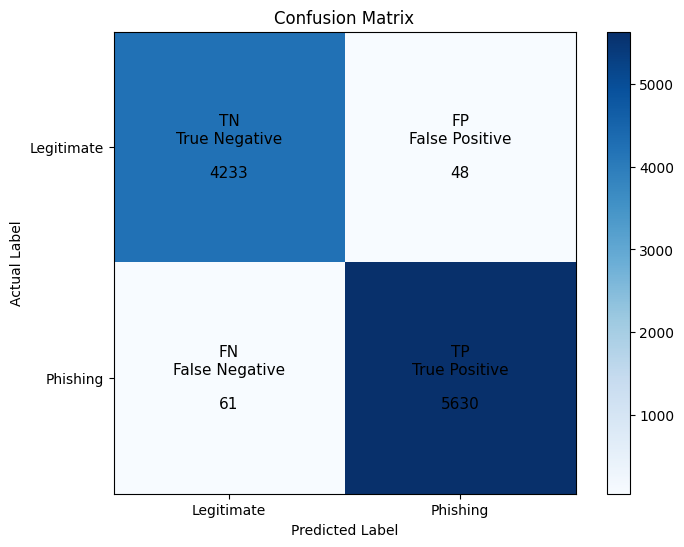

,Feature,Importance
9910,wrote,0.038597
5244,list,0.022372
3151,emailtoken,0.017916
9514,version,0.010806
3185,emailtoken urltoken,0.010103
99,10,0.009902
2567,date,0.009265
7107,python,0.009033
5442,mailing list,0.008838
6291,opensuse,0.008497


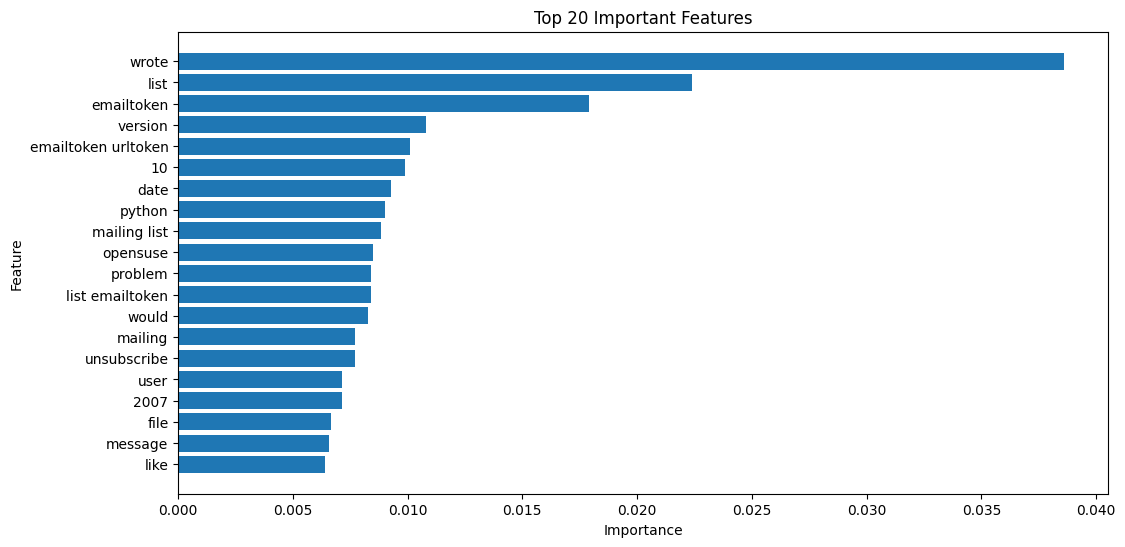


===== SAVED FILES =====
['rf_model.pkl', 'tfidf.pkl']


In [10]:
# 7: Đánh giá, Feature Importance, lưu model

# STEP 1:  PREDICT
y_pred = rf_model.predict(X_test)


# STEP 2
print("===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred))


# STEP 3: CONFUSION MATRIX

import numpy as np
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()
labels = np.array(
    [
        f"TN\nTrue Negative\n\n{TN}",
        f"FP\nFalse Positive\n\n{FP}",
        f"FN\nFalse Negative\n\n{FN}",
        f"TP\nTrue Positive\n\n{TP}",
    ]
).reshape(2, 2)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im)
for i in range(2):

    for j in range(2):

        ax.text(
            j, i, labels[i, j], ha="center", va="center", fontsize=11, color="black"
        )

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Legitimate", "Phishing"])
ax.set_yticklabels(["Legitimate", "Phishing"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()


# STEP 4: FEATURE IMPORTANCE
feature_importances = rf_model.feature_importances_
feature_names = tfidf.get_feature_names_out()
importance_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": feature_importances}
)
importance_df = importance_df.sort_values(by="Importance", ascending=False)
top20 = importance_df.head(20)
display(top20)
plt.figure(figsize=(12, 6))
plt.barh(top20["Feature"], top20["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Important Features")
plt.gca().invert_yaxis()
plt.show()

# STEP 5: SAVE MODEL
import joblib

joblib.dump(rf_model, model_dir / "rf_model.pkl")
joblib.dump(tfidf, model_dir / "tfidf.pkl")
print("\n===== SAVED FILES =====")
print(os.listdir(model_dir))